In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_curve, roc_auc_score

import pandas as pd
import numpy as np
import os
import random
import time

import matplotlib.pyplot as plt

import utils.parser as parser

In [2]:
# Process diagnosis data 
metadata = pd.read_csv('SJBae/all_metadata_contig_stats.csv')
diagnosis_data = metadata[['External ID', 'diagnosis']]
diagnosis_data = diagnosis_data.set_index(diagnosis_data.columns[0])

#print(diagnosis_data.shape)
#diagnosis_data.head()
#counts = diagnosis_data['diagnosis'].value_counts()
#print(counts)

In [3]:
# Process taxonomic data - genus 

genus_filtered_data = pd.read_csv('taxonomic_profiles_3_genus_filter.tsv', sep='\t', index_col=0)
genus_filtered_data = genus_filtered_data.T

#print(genus_filtered_data.shape)
#genus_filtered_data.head()

In [4]:
# Process taxonomic data - species 

species_filtered_data = pd.read_csv('taxonomic_profiles_3_species_filter.tsv', sep='\t', index_col=0)
species_filtered_data = species_filtered_data.T

#print(species_filtered_data.shape)
#species_filtered_data.head()

In [5]:
class AbundanceDataset(Dataset): 
    def __init__(self, abundances, labels, binary=False):
        self.abundances = abundances
        self.labels = labels

        if binary: 
            self.label_tokenizer = {"nonIBD":0, "CD":1, "UC": 1}
        else:
            self.label_tokenizer = {"nonIBD":0, "CD":1, "UC": 2}
        
        self.data = []
        for sample in abundances.index:
            features = abundances.loc[sample].values.astype(float)  # 1D array
            label = self.label_tokenizer[labels.loc[sample]]
            self.data.append((features, label))
            
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        features, label = self.data[idx]
        return torch.tensor(features, dtype=torch.float32), torch.tensor(label)

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class Abundance1DCNN(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.fc1 = nn.Linear((n_features//2) * 32, 64)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)  
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)  
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [7]:
def compute_metrics(y_true, y_pred, binary=False):
    
    y_true = torch.stack(y_true).numpy().flatten().tolist()
    y_pred = torch.stack(y_pred).numpy().flatten().tolist()

    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred, average='binary' if binary else 'micro')
    precision = precision_score(y_true, y_pred, average='binary' if binary else 'micro')
    
    return accuracy, recall, precision

def plot_metrics(epochs, metrics):
    epochs_range = range(1, epochs + 1)
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    
    # Loss
    axs[0, 0].plot(epochs_range, metrics[0], label='Train Loss')
    axs[0, 0].plot(epochs_range, metrics[1], label='Test Loss')
    axs[0, 0].set_title('Loss')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend(loc='lower left')
    
    # Accuracy
    axs[0, 1].plot(epochs_range, metrics[2], label='Train Accuracy')
    axs[0, 1].plot(epochs_range, metrics[3], label='Test Accuracy')
    axs[0, 1].set_title('Accuracy')
    axs[0, 1].set_xlabel('Epoch')
    axs[0, 1].set_ylabel('Accuracy')
    axs[0, 1].legend(loc='lower left')
    
    # Recall
    axs[1, 0].plot(epochs_range, metrics[4], label='Train Recall')
    axs[1, 0].plot(epochs_range, metrics[5], label='Test Recall')
    axs[1, 0].set_title('Recall')
    axs[1, 0].set_xlabel('Epoch')
    axs[1, 0].set_ylabel('Recall')
    axs[1, 0].legend(loc='lower left')
    
    # Precision
    axs[1, 1].plot(epochs_range, metrics[6], label='Train Precision')
    axs[1, 1].plot(epochs_range, metrics[7], label='Test Precision')
    axs[1, 1].set_title('Precision')
    axs[1, 1].set_xlabel('Epoch')
    axs[1, 1].set_ylabel('Precision')
    axs[1, 1].legend(loc='lower left')
    
    plt.tight_layout()
    plt.show()

In [8]:
def train_model(model, train_loader, test_loader, criterion, optimizer, device, epochs): 

    # Make lists to hold metrics for plotting 
    train_losses, test_losses = [], []
    train_accuracies, test_accuracies = [], []
    train_recalls, test_recalls = [], []
    train_precisions, test_precisions = [], []

    start_time = time.time()
    
    for epoch in range(epochs):
    
        # Train model and evaluate
        model.train()
        preds = []
        ground = []
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            
            loss.backward()
            optimizer.step()
            
            preds.extend(logits.argmax(dim=1).cpu().detach())
            ground.extend(labels.cpu().detach())
            
            running_loss += loss.item()
            
        train_accuracy, train_recall, train_precision = compute_metrics(ground, preds)
    
        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(train_accuracy)
        train_recalls.append(train_recall)
        train_precisions.append(train_precision)

        # Evaluate model on test set 
        model.eval()
        preds = []
        ground = []
        test_loss = 0.0
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                logits = model(inputs)    
                loss = criterion(logits, labels)
    
                preds.extend(logits.argmax(dim=1).cpu().detach())
                ground.extend(labels.cpu().detach()) 
                
                test_loss += loss.item()
    
        test_accuracy, test_recall, test_precision = compute_metrics(ground, preds)
        
        test_losses.append(test_loss / len(test_loader))
        test_accuracies.append(test_accuracy)
        test_recalls.append(test_recall)
        test_precisions.append(test_precision)

        if (epoch)%10==0:
            print(f"Epoch {epoch+1}/{epochs}")
            print(f"Train Loss: {running_loss/len(train_loader)}, Test Loss: {test_loss/len(test_loader)}")
            print(f"Train Accuracy: {train_accuracy:.4f}, Train Recall: {train_recall:.4f}, Train Precision: {train_precision:.4f}")
            print(f"Test Accuracy: {test_accuracy:.4f}, Test Recall: {test_recall:.4f}, Test Precision: {test_precision:.4f}\n")

    end_time = time.time()
    print(f"Time to train: {end_time-start_time:.2f} seconds\n")

    metrics = [train_losses, test_losses, 
               train_accuracies, test_accuracies, 
               train_recalls, test_recalls, 
               train_precisions, test_precisions]

    return model, metrics 

In [9]:
def train_and_evaluate(taxonomic_data, diagnosis_data, binary, device, epochs, batch_size):
    '''
    Trains and evaluates a 1D CNN on taxonomic abundance data.

    Parameters
        taxonomic_data : pd.DataFrame
            DataFrame of abundances for each sample (samples x features).
        diagnosis_data : pd.DataFrame
            DataFrame with a 'diagnosis' column for each sample.
        binary : bool
            True for healthy vs disease, False for CD vs UC vs healthy.
        device : torch.device
            Device to train on.
        epochs : int
            Number of training epochs.
        batch_size : int
            Batch size for training and evaluation.

    Returns
        metrics : list 
            List of metric lists for plotting.
        
    '''
    # Align features and labels by sample 
    X = taxonomic_data.sort_index()
    y = diagnosis_data['diagnosis'].sort_index()
    
    # Split data into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

    # Create datasets and loaders
    train_dataset = AbundanceDataset(X_train, y_train, binary=binary)
    test_dataset = AbundanceDataset(X_test, y_test, binary=binary)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Model setup
    n_features = X.shape[1]
    n_classes = 2 if binary else 3

    model = Abundance1DCNN(n_features, n_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # Train and evaluate
    model, metrics = train_model(model, train_loader, test_loader, criterion, optimizer, device, epochs)

    plot_metrics(epochs, metrics)

    return model 

In [10]:
# Set device
device = 'mps' if torch.mps.is_available() else 'cpu'

In [11]:
import matplotlib.pyplot as plt

def plot_multiple_batch_metrics(epochs, opt_metrics, batch_sizes):
    epochs_range = range(1, epochs + 1)
    metric_names = ['Loss', 'Accuracy', 'Recall', 'Precision']
    train_indices = [0, 2, 4, 6]
    test_indices = [1, 3, 5, 7]
    colors = ['#377eb8', '#ff7f00', '#4daf4a']  # blue, orange, green

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    for i, (name, train_idx, test_idx) in enumerate(zip(metric_names, train_indices, test_indices)):
        ax = axs[i // 2, i % 2]
        for j, (metrics, batch_size) in enumerate(zip(opt_metrics, batch_sizes)):
            ax.plot(epochs_range, metrics[train_idx], label=f'Train, batch={batch_size}', color=colors[j], linestyle='-')
            ax.plot(epochs_range, metrics[test_idx], label=f'Test, batch={batch_size}', color=colors[j], linestyle='--')
        ax.set_title(name)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(name)
        ax.legend(loc='lower left')
    plt.tight_layout()
    plt.show()


Epoch 1/50
Train Loss: 0.5431560234325689, Test Loss: 0.45123607462102716
Train Accuracy: 0.7191, Train Recall: 0.7191, Train Precision: 0.7191
Test Accuracy: 0.7470, Test Recall: 0.7470, Test Precision: 0.7470

Epoch 11/50
Train Loss: 0.15796420859490953, Test Loss: 0.26279061287641525
Train Accuracy: 0.9466, Train Recall: 0.9466, Train Precision: 0.9466
Test Accuracy: 0.9116, Test Recall: 0.9116, Test Precision: 0.9116

Epoch 21/50
Train Loss: 0.04910962781073844, Test Loss: 0.208655060692267
Train Accuracy: 0.9901, Train Recall: 0.9901, Train Precision: 0.9901
Test Accuracy: 0.9390, Test Recall: 0.9390, Test Precision: 0.9390

Epoch 31/50
Train Loss: 0.026710489662591277, Test Loss: 0.22561548853462393
Train Accuracy: 0.9924, Train Recall: 0.9924, Train Precision: 0.9924
Test Accuracy: 0.9390, Test Recall: 0.9390, Test Precision: 0.9390

Epoch 41/50
Train Loss: 0.0735118010439115, Test Loss: 0.20329453965479677
Train Accuracy: 0.9840, Train Recall: 0.9840, Train Precision: 0.9840
Te

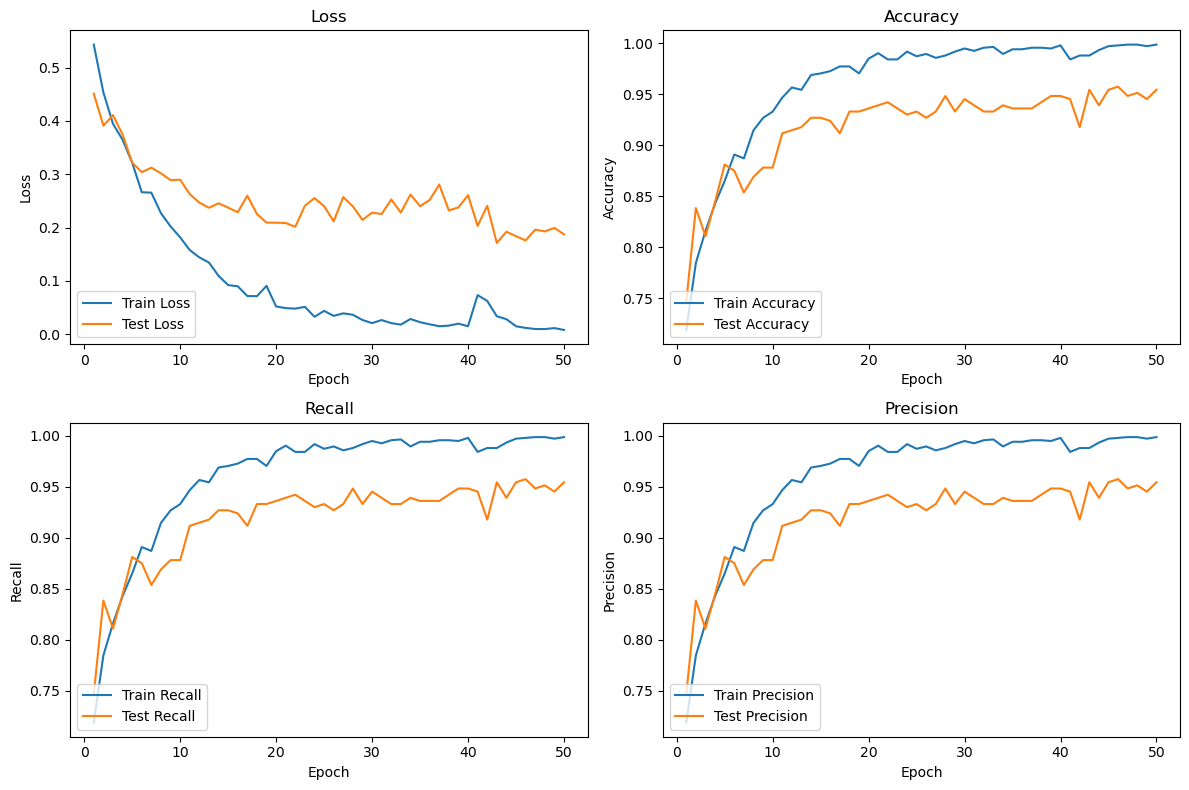

In [12]:
# Binary prediction (healthy vs disease) with filtered species data 
model = train_and_evaluate(species_filtered_data, diagnosis_data, binary=True, device=device, epochs=50, batch_size=32)

Epoch 1/50
Train Loss: 0.9851213490090719, Test Loss: 0.9217035228555853
Train Accuracy: 0.5160, Train Recall: 0.5160, Train Precision: 0.5160
Test Accuracy: 0.5396, Test Recall: 0.5396, Test Precision: 0.5396

Epoch 11/50
Train Loss: 0.26220402703052614, Test Loss: 0.880917259237983
Train Accuracy: 0.9038, Train Recall: 0.9038, Train Precision: 0.9038
Test Accuracy: 0.7470, Test Recall: 0.7470, Test Precision: 0.7470

Epoch 21/50
Train Loss: 0.07892347408867464, Test Loss: 0.8606666069139134
Train Accuracy: 0.9794, Train Recall: 0.9794, Train Precision: 0.9794
Test Accuracy: 0.8780, Test Recall: 0.8780, Test Precision: 0.8780

Epoch 31/50
Train Loss: 0.04402655741290712, Test Loss: 0.9978555264798078
Train Accuracy: 0.9893, Train Recall: 0.9893, Train Precision: 0.9893
Test Accuracy: 0.8720, Test Recall: 0.8720, Test Precision: 0.8720

Epoch 41/50
Train Loss: 0.0229224837441906, Test Loss: 1.1008179648356005
Train Accuracy: 0.9939, Train Recall: 0.9939, Train Precision: 0.9939
Test Ac

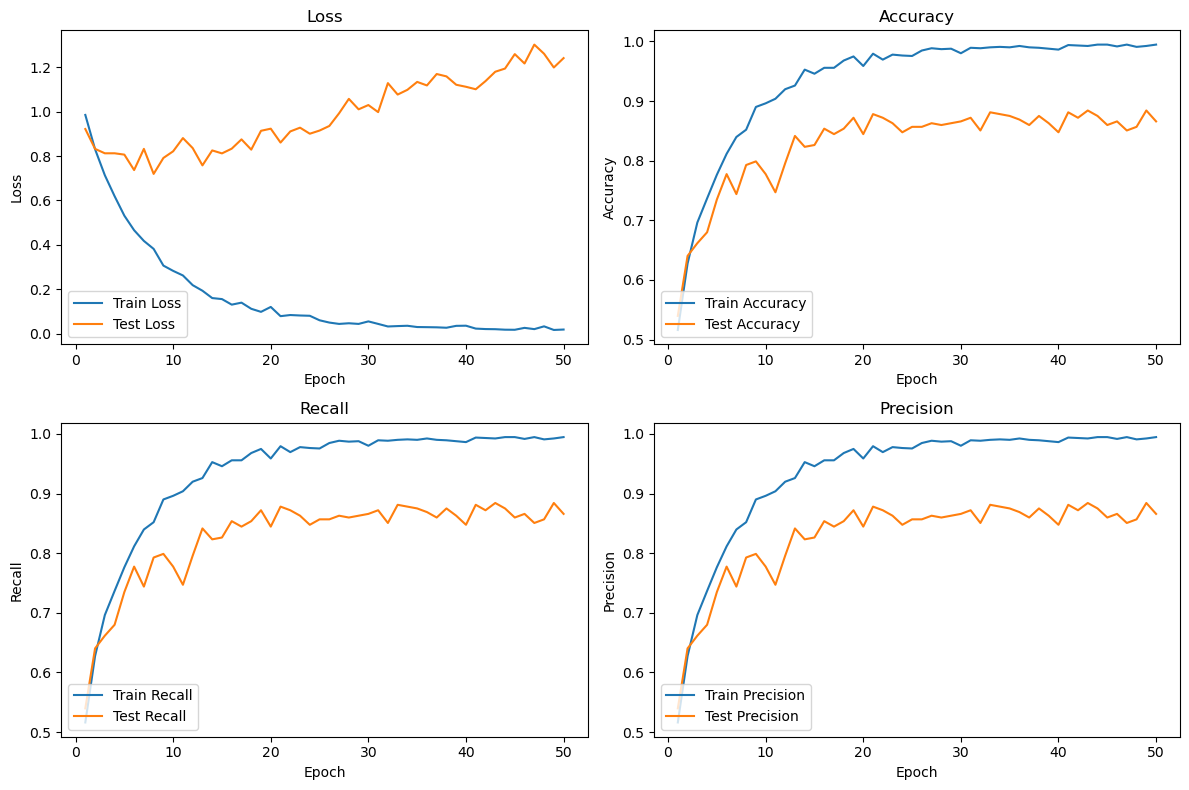

In [13]:
# CD vs UC vs healthy prediction with filtered species data 
model = train_and_evaluate(species_filtered_data, diagnosis_data, binary=False, device=device, epochs=50, batch_size=32)

Epoch 1/50
Train Loss: 0.5577482355803978, Test Loss: 0.5204678448763761
Train Accuracy: 0.7382, Train Recall: 0.7382, Train Precision: 0.7382
Test Accuracy: 0.7409, Test Recall: 0.7409, Test Precision: 0.7409

Epoch 11/50
Train Loss: 0.34749250077619787, Test Loss: 0.4330400905825875
Train Accuracy: 0.8588, Train Recall: 0.8588, Train Precision: 0.8588
Test Accuracy: 0.8354, Test Recall: 0.8354, Test Precision: 0.8354

Epoch 21/50
Train Loss: 0.21347630278366367, Test Loss: 0.4287380968982523
Train Accuracy: 0.9160, Train Recall: 0.9160, Train Precision: 0.9160
Test Accuracy: 0.8506, Test Recall: 0.8506, Test Precision: 0.8506

Epoch 31/50
Train Loss: 0.14668205475843535, Test Loss: 0.39109213108366186
Train Accuracy: 0.9473, Train Recall: 0.9473, Train Precision: 0.9473
Test Accuracy: 0.8598, Test Recall: 0.8598, Test Precision: 0.8598

Epoch 41/50
Train Loss: 0.09042941742553944, Test Loss: 0.3301888226785443
Train Accuracy: 0.9649, Train Recall: 0.9649, Train Precision: 0.9649
Test

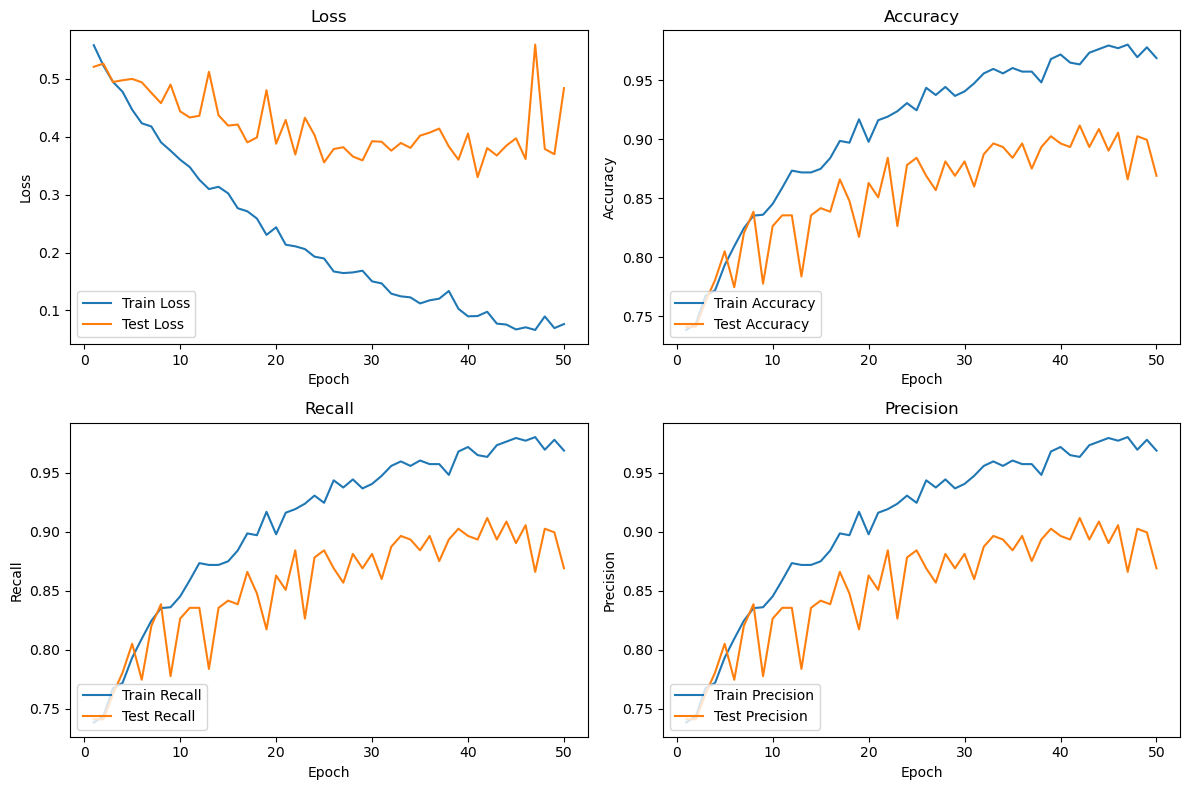

In [14]:
# Binary prediction (healthy vs disease) with filtered genus data 
model = train_and_evaluate(genus_filtered_data, diagnosis_data, binary=True, device=device, epochs=50, batch_size=32)

Epoch 1/50
Train Loss: 1.0319224988541953, Test Loss: 1.018444007093256
Train Accuracy: 0.4969, Train Recall: 0.4969, Train Precision: 0.4969
Test Accuracy: 0.5000, Test Recall: 0.5000, Test Precision: 0.5000

Epoch 11/50
Train Loss: 0.6197784041486135, Test Loss: 0.7965078760277141
Train Accuracy: 0.7374, Train Recall: 0.7374, Train Precision: 0.7374
Test Accuracy: 0.6677, Test Recall: 0.6677, Test Precision: 0.6677

Epoch 21/50
Train Loss: 0.4263409790469379, Test Loss: 0.7765411931005392
Train Accuracy: 0.8260, Train Recall: 0.8260, Train Precision: 0.8260
Test Accuracy: 0.7256, Test Recall: 0.7256, Test Precision: 0.7256

Epoch 31/50
Train Loss: 0.2907753092486684, Test Loss: 0.8510004126212813
Train Accuracy: 0.8969, Train Recall: 0.8969, Train Precision: 0.8969
Test Accuracy: 0.7683, Test Recall: 0.7683, Test Precision: 0.7683

Epoch 41/50
Train Loss: 0.19706735723629232, Test Loss: 1.043102622709491
Train Accuracy: 0.9275, Train Recall: 0.9275, Train Precision: 0.9275
Test Accur

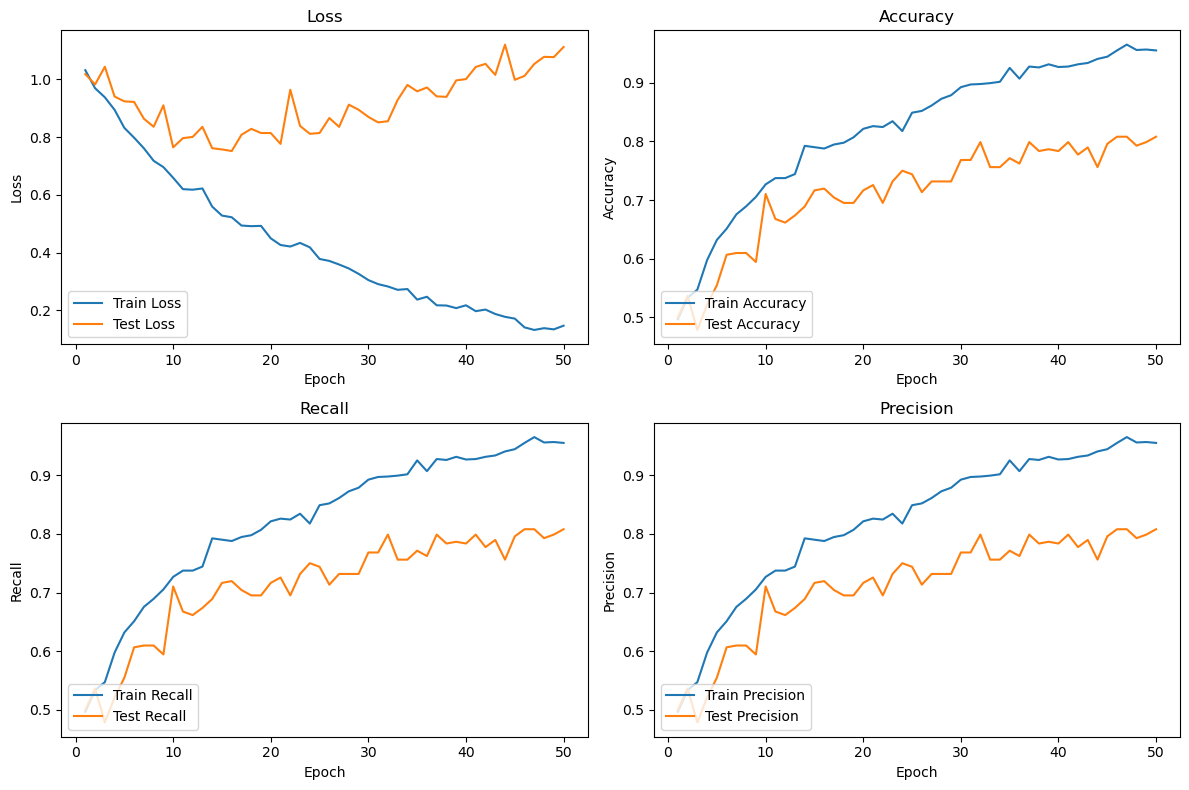

In [15]:
# CD vs UC vs healthy prediction with filtered genus data 
model = train_and_evaluate(genus_filtered_data, diagnosis_data, binary=False, device=device, epochs=50, batch_size=32)